# MVP — Análise Exploratória e Pré-processamento de Dados

## Fatores Associados ao Preço de Imóveis em Cidades Canadenses

**Aluno(a):** Luiza Oliveira Lima  
**Disciplina:** Análise de Dados e Boas Práticas  
**Objetivo do projeto:** realizar uma análise exploratória e o pré-processamento de uma base de dados de imóveis no Canadá, investigando fatores associados à variação dos preços.

## 1. Introdução

O mercado imobiliário é um dos principais componentes do custo de vida no Canadá, especialmente nas grandes cidades. Nesse contexto, analisar dados de imóveis pode contribuir para a compreensão dos fatores que influenciam a variação dos preços anunciados.

Este projeto tem como objetivo explorar uma base de dados pública com informações de imóveis em cidades canadenses, buscando identificar padrões relevantes entre o preço e características como quantidade de quartos, quantidade de banheiros, cidade e província. Além da análise exploratória, também será realizado o pré-processamento dos dados, preparando a base para possíveis etapas futuras de modelagem preditiva.

# Descrição do problema

A pergunta central deste projeto é:

**Quais características dos imóveis e da localização estão mais associadas à variação dos preços de imóveis em cidades canadenses?**

Trata-se de um problema relevante porque o preço da moradia exerce grande impacto sobre o custo de vida, influenciando decisões de compra, investimento e mudança de cidade.

## 2. Objetivos

### Objetivo geral
Realizar uma análise exploratória e o pré-processamento de um conjunto de dados de imóveis no Canadá, com o intuito de identificar padrões relacionados aos preços dos imóveis.

### Objetivos específicos
- Examinar a estrutura e a qualidade da base de dados;
- Analisar a distribuição dos preços dos imóveis;
- Investigar a relação entre preço e atributos dos imóveis;
- Comparar preços entre cidades e províncias;
- Identificar valores faltantes, inconsistências e possíveis outliers;
- Aplicar técnicas de pré-processamento para preparar a base para análises futuras.

## 3. Hipóteses

As hipóteses iniciais deste projeto são:

1. Imóveis com mais quartos tendem a ter preços mais altos?;
2. A localização influencia o preço dos imóveis?;
3. Variáveis como renda e população estão associadas ao preço?

## 4. Tipo de problema

Este projeto está relacionado a um problema de aprendizado supervisionado do tipo **regressão**, uma vez que o preço do imóvel pode ser tratado como variável-alvo em análises futuras.

No entanto, nesta etapa do MVP, o foco está na **análise exploratória** e no **pré-processamento dos dados**, com o objetivo de compreender a base e prepará-la adequadamente para usos posteriores.

# Importação das bibliotecas e carga de dados


## 5. Fonte dos dados

O dataset utilizado neste projeto foi obtido em uma fonte pública e disponibilizado em repositório no GitHub para fins de reprodutibilidade. A leitura dos dados será feita diretamente no Google Colab por meio do link raw do arquivo CSV.

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [135]:
url = "https://raw.githubusercontent.com/luizaoliveirali/mvp-imoveis-canada/main/canada_houses.csv"
df = pd.read_csv(url, encoding="latin1")

## 6. Leitura e visualização inicial dos dados

Após a importação das bibliotecas e leitura do arquivo CSV, será feita uma inspeção inicial da base para compreender sua estrutura, visualizar as primeiras linhas e identificar os tipos de variáveis presentes.

In [136]:
df.head()

,City,Price,Address,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
0,Toronto,779900.0,#318 -20 SOUTHPORT ST,3,2,Ontario,5647656,43.7417,-79.3733,97000.0
1,Toronto,799999.0,#818 -60 SOUTHPORT ST,3,1,Ontario,5647656,43.7417,-79.3733,97000.0
2,Toronto,799900.0,#714 -859 THE QUEENSWAY,2,2,Ontario,5647656,43.7417,-79.3733,97000.0
3,Toronto,1200000.0,275 MORTIMER AVE,4,2,Ontario,5647656,43.7417,-79.3733,97000.0
4,Toronto,668800.0,#420 -388 RICHMOND ST,1,1,Ontario,5647656,43.7417,-79.3733,97000.0


## 7. Dimensão da base

Nesta etapa, será verificado o tamanho do conjunto de dados, ou seja, a quantidade de linhas e colunas disponíveis para análise.

In [137]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 35768
Quantidade de colunas: 10


## 8. Tipos de dados e estrutura da base

A seguir, será analisada a estrutura da base de dados, com foco nos nomes das colunas, tipos de dados e quantidade de valores não nulos em cada variável.

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35768 entries, 0 to 35767
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   City                  35768 non-null  object 
 1   Price                 35768 non-null  float64
 2   Address               35768 non-null  object 
 3   Number_Beds           35768 non-null  int64  
 4   Number_Baths          35768 non-null  int64  
 5   Province              35768 non-null  object 
 6   Population            35768 non-null  int64  
 7   Latitude              35768 non-null  float64
 8   Longitude             35768 non-null  float64
 9   Median_Family_Income  35768 non-null  float64
dtypes: float64(4), int64(3), object(3)
memory usage: 2.7+ MB


In [139]:
list(df.columns)

['City',
 'Price',
 'Address',
 'Number_Beds',
 'Number_Baths',
 'Province',
 'Population',
 'Latitude',
 'Longitude',
 'Median_Family_Income']

# Análise de Dados

## 9. Verificação de valores ausentes

A identificação de valores ausentes é importante para avaliar a qualidade da base e definir quais técnicas de tratamento serão necessárias durante o pré-processamento.

In [140]:
df.isnull().sum()

,0
City,0
Price,0
Address,0
Number_Beds,0
Number_Baths,0
Province,0
Population,0
Latitude,0
Longitude,0
Median_Family_Income,0


## 10. Estatísticas descritivas

As estatísticas descritivas permitem uma primeira compreensão do comportamento das variáveis numéricas, incluindo medidas como média, desvio padrão, valor mínimo, quartis e valor máximo.

In [141]:
df.describe()

,Price,Number_Beds,Number_Baths,Population,Latitude,Longitude,Median_Family_Income
count,3.576800e+04,35768.000000,35768.000000,3.576800e+04,35768.000000,35768.000000,35768.000000
mean,9.432963e+05,3.283661,2.532403,6.360151e+05,47.446556,-98.421636,89643.103416
std,1.020110e+06,1.730654,1.371910,1.120016e+06,3.333855,22.280935,12132.353510
min,2.150000e+04,0.000000,0.000000,6.338200e+04,42.283300,-123.936400,62400.000000
25%,4.599000e+05,2.000000,2.000000,1.091670e+05,43.866700,-122.316700,82000.000000
50%,6.990000e+05,3.000000,2.000000,2.424600e+05,49.025000,-104.606700,89000.000000
75%,1.095000e+06,4.000000,3.000000,5.228880e+05,49.888100,-79.866700,97000.000000
max,3.700000e+07,109.000000,59.000000,5.647656e+06,53.916900,63.100500,133000.000000


## 11. Verificação de registros duplicados

Nesta etapa, será verificada a existência de registros duplicados, pois esse tipo de ocorrência pode comprometer a qualidade das análises e dos resultados.

In [142]:
df.duplicated().sum()

np.int64(2516)

## 12. Dicionário das variáveis

A base de dados utilizada neste projeto contém as seguintes variáveis:

- **City**: cidade onde o imóvel está localizado;
- **Price**: preço do imóvel;
- **Address**: endereço do imóvel;
- **Number_Beds**: número de quartos;
- **Number_Baths**: número de banheiros;
- **Province**: província do Canadá;
- **Population**: população da cidade;
- **Latitude**: latitude da localização do imóvel;
- **Longitude**: longitude da localização do imóvel;
- **Median_Family_Income**: renda familiar mediana da localidade.

Essas variáveis permitem investigar tanto características físicas dos imóveis quanto fatores relacionados à localização.

## 13. Percentual de valores ausentes

Além da contagem de valores ausentes, também é importante verificar o percentual de ausência em cada coluna, pois isso ajuda a avaliar o impacto potencial desses dados faltantes na análise.

In [143]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
City,0.0
Price,0.0
Address,0.0
Number_Beds,0.0
Number_Baths,0.0
Province,0.0
Population,0.0
Latitude,0.0
Longitude,0.0
Median_Family_Income,0.0


In [144]:
print(f"Quantidade de registros duplicados: {df.duplicated().sum()}")

Quantidade de registros duplicados: 2516


A verificação de duplicados identificou a presença de 2516 registros repetidos na base de dados.

A existência de duplicatas pode impactar negativamente as análises, uma vez que determinados imóveis podem ser contabilizados mais de uma vez, distorcendo métricas como médias e distribuições.

Dessa forma, será necessário remover esses registros na etapa de pré-processamento, garantindo maior consistência e confiabilidade nos resultados.

## 14. Estatísticas descritivas das variáveis numéricas

Nesta etapa, são analisadas medidas descritivas das variáveis numéricas da base, como média, desvio padrão, mínimo, máximo e quartis. Isso permite uma primeira visão sobre dispersão, concentração e possíveis valores extremos.

In [145]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,35768.0,943296.251812,1.020110e+06,21500.0000,459900.0000,699000.0000,1.095000e+06,3.700000e+07
Number_Beds,35768.0,3.283661,1.730654e+00,0.0000,2.0000,3.0000,4.000000e+00,1.090000e+02
Number_Baths,35768.0,2.532403,1.371910e+00,0.0000,2.0000,2.0000,3.000000e+00,5.900000e+01
Population,35768.0,636015.093268,1.120016e+06,63382.0000,109167.0000,242460.0000,5.228880e+05,5.647656e+06
Latitude,35768.0,47.446556,3.333855e+00,42.2833,43.8667,49.0250,4.988810e+01,5.391690e+01
Longitude,35768.0,-98.421636,2.228094e+01,-123.9364,-122.3167,-104.6067,-7.986670e+01,6.310050e+01
Median_Family_Income,35768.0,89643.103416,1.213235e+04,62400.0000,82000.0000,89000.0000,9.700000e+04,1.330000e+05


A análise das estatísticas descritivas evidencia uma alta variabilidade nos dados, especialmente na variável de preço dos imóveis. Observa-se que a média (aproximadamente 943 mil) é superior à mediana (cerca de 699 mil), indicando uma distribuição assimétrica à direita, característica comum em dados imobiliários.

Além disso, o valor máximo registrado (37 milhões) sugere a presença de imóveis com preços extremamente elevados, configurando possíveis outliers que podem influenciar significativamente as análises.

Em relação às características dos imóveis, a maior parte apresenta entre 2 e 4 quartos e entre 2 e 3 banheiros, o que indica um padrão predominante na base. No entanto, valores máximos muito elevados, como 109 quartos e 59 banheiros, reforçam a presença de registros atípicos.

As variáveis relacionadas à localização, como população e renda familiar mediana, apresentam variações relevantes entre as cidades, o que pode contribuir para diferenças nos preços dos imóveis.

De modo geral, os resultados indicam a necessidade de atenção especial aos outliers, principalmente na variável preço, os quais poderão ser tratados na etapa de pré-processamento.

## 15. Distribuição da variável preço

A variável preço é central neste projeto, pois representa o valor do imóvel e será a principal variável de interesse. O histograma abaixo permite observar como os preços estão distribuídos e se existem indícios de assimetria ou concentração em determinadas faixas de valor.

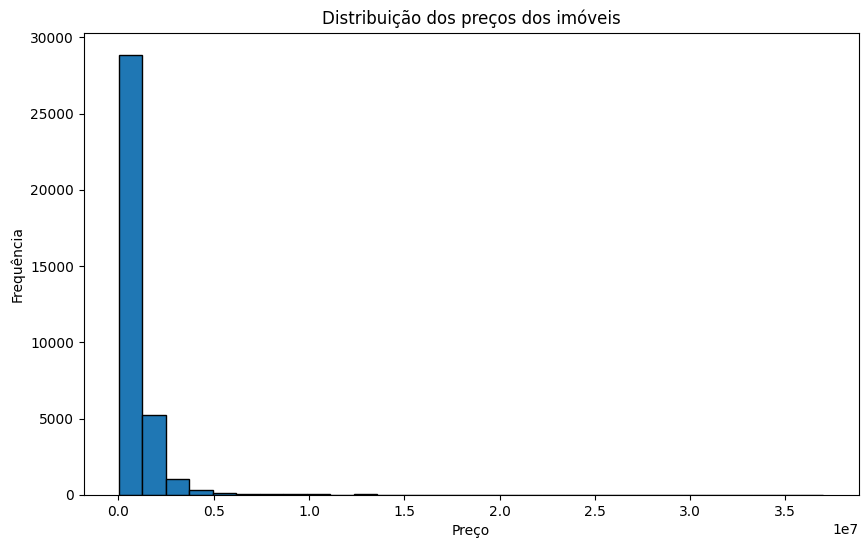

In [146]:
plt.figure(figsize=(10,6))
plt.hist(df["Price"].dropna(), bins=30, edgecolor="black")
plt.title("Distribuição dos preços dos imóveis")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

A distribuição dos preços dos imóveis apresenta forte assimetria à direita, com grande concentração de observações em faixas de preço mais baixas e uma cauda longa composta por imóveis com valores significativamente mais elevados.

Esse comportamento indica que a maior parte dos imóveis da base possui preços mais acessíveis, enquanto uma pequena parcela apresenta valores muito altos, caracterizando possíveis outliers.

Essa distribuição reforça os resultados observados nas estatísticas descritivas, em que a média é superior à mediana, evidenciando que os valores extremos influenciam a média. Dessa forma, a mediana se mostra uma medida mais representativa do comportamento típico dos preços na base.

Além disso, a presença de valores extremos sugere a necessidade de atenção na etapa de pré-processamento, especialmente no tratamento de outliers.

## 16. Identificação visual de outliers no preço

O boxplot é útil para identificar possíveis valores extremos na variável preço. Em bases imobiliárias, é comum que existam imóveis muito acima da média, o que pode influenciar análises estatísticas e etapas futuras de modelagem.

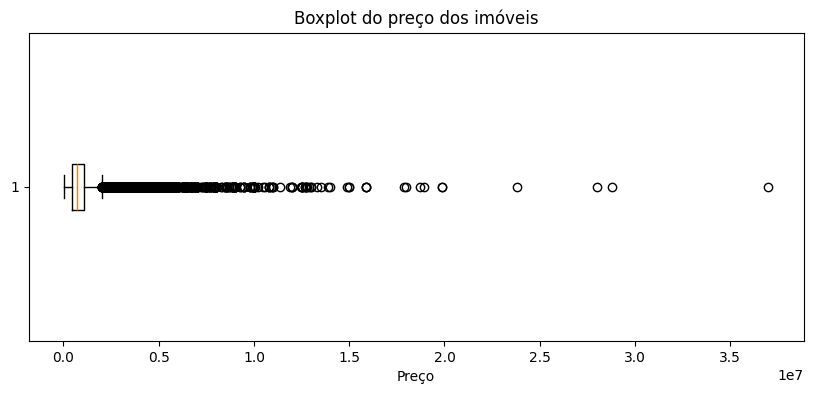

In [147]:
plt.figure(figsize=(10,4))
plt.boxplot(df["Price"].dropna(), vert=False)
plt.title("Boxplot do preço dos imóveis")
plt.xlabel("Preço")
plt.show()

O boxplot da variável preço evidencia de forma clara a presença de diversos valores extremos na base. A maior parte dos imóveis está concentrada em uma faixa de preços mais baixa, enquanto vários registros aparecem muito distantes da distribuição principal.

Esse comportamento confirma a assimetria observada anteriormente no histograma e nas estatísticas descritivas, reforçando que a base contém imóveis com preços muito acima do padrão predominante.

Em termos analíticos, esses outliers podem influenciar medidas como média e desvio padrão, além de impactar visualizações e possíveis modelos preditivos. Por esse motivo, o tratamento de valores extremos na variável preço se mostra uma etapa relevante no pré-processamento dos dados.

## 17. Distribuição do número de quartos

A quantidade de quartos é uma característica importante do imóvel e pode influenciar diretamente seu preço. A análise dessa variável permite entender quais perfis de imóveis predominam na base.

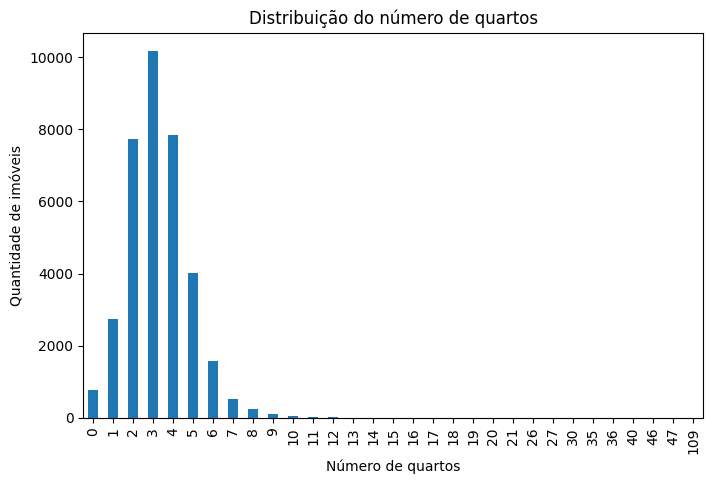

In [148]:
plt.figure(figsize=(8,5))
df["Number_Beds"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição do número de quartos")
plt.xlabel("Número de quartos")
plt.ylabel("Quantidade de imóveis")
plt.show()

A distribuição do número de quartos indica que a maior parte dos imóveis da base está concentrada entre 2 e 4 quartos, com destaque para imóveis de 3 quartos, que representam o grupo mais frequente.

Esse padrão sugere que a base é composta predominantemente por imóveis de porte médio, característicos do mercado residencial típico.

Por outro lado, observa-se a presença de valores elevados e pouco frequentes, como imóveis com mais de 6 quartos e até valores extremos, o que indica a existência de outliers na variável. Esses registros não representam o comportamento predominante da base e podem exigir tratamento específico nas etapas posteriores de análise.

## 18. Distribuição do número de banheiros

Assim como o número de quartos, a quantidade de banheiros é um atributo relevante para a caracterização do imóvel e pode estar associada ao valor anunciado.

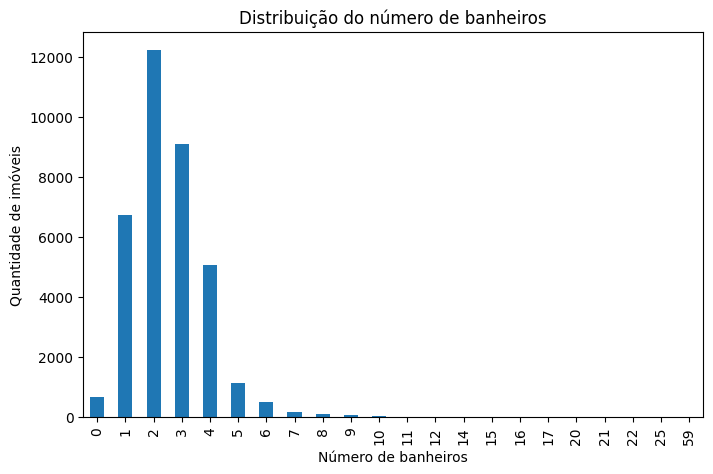

In [149]:
plt.figure(figsize=(8,5))
df["Number_Baths"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição do número de banheiros")
plt.xlabel("Número de banheiros")
plt.ylabel("Quantidade de imóveis")
plt.show()

A distribuição do número de banheiros mostra que a maior parte dos imóveis possui entre 2 e 3 banheiros, com predominância de imóveis com 2 banheiros.

Esse padrão é consistente com a distribuição do número de quartos observada anteriormente, indicando que a base apresenta um perfil coerente de imóveis de porte médio.

Assim como na variável de quartos, também são observados valores extremos pouco frequentes, como imóveis com um número muito elevado de banheiros. Esses casos representam outliers e não refletem o comportamento predominante da base, podendo impactar análises estatísticas e devendo ser considerados na etapa de pré-processamento.

## 19. Comparação de preços médios por cidade

A localização é um dos principais fatores associados ao preço dos imóveis. Assim, comparar o preço médio entre cidades pode evidenciar diferenças importantes no mercado imobiliário canadense.

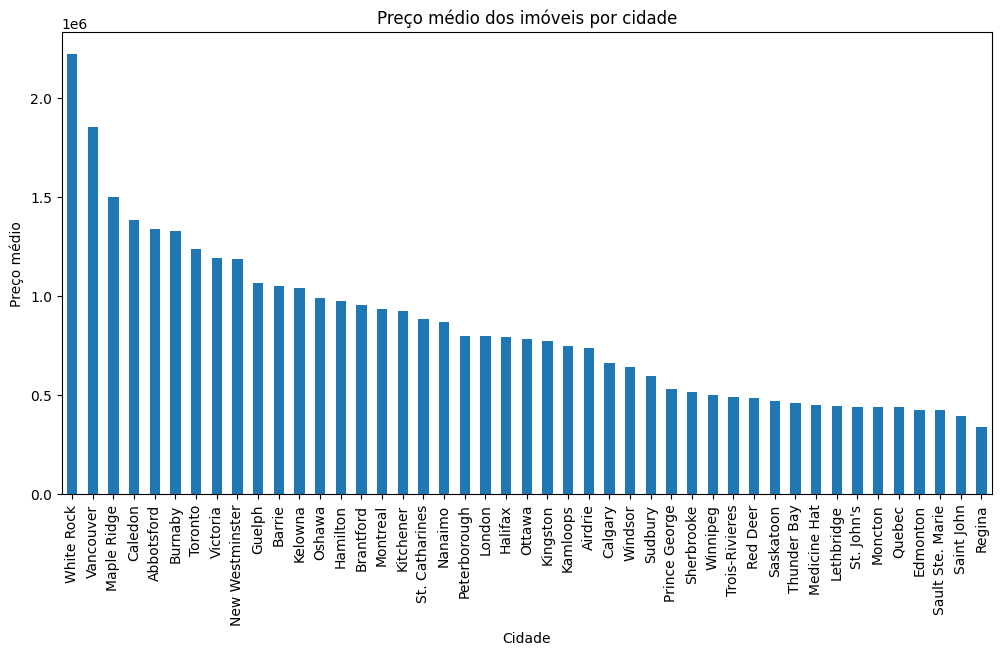

In [150]:
preco_medio_cidade = df.groupby("City")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
preco_medio_cidade.plot(kind="bar")
plt.title("Preço médio dos imóveis por cidade")
plt.xlabel("Cidade")
plt.ylabel("Preço médio")
plt.show()

A comparação dos preços médios por cidade evidencia diferenças expressivas entre os mercados imobiliários presentes na base. Algumas cidades, como White Rock e Vancouver, apresentam preços médios significativamente superiores aos observados em outras localidades, enquanto cidades como Regina aparecem entre as de menor valor médio.

Esse resultado reforça a importância da localização como fator associado ao preço dos imóveis, indicando que o mercado imobiliário canadense não se comporta de forma homogênea entre as cidades analisadas.

Além disso, a amplitude observada entre os maiores e menores valores médios sugere que fatores locais, como perfil urbano, valorização regional e características socioeconômicas, podem influenciar de maneira relevante os preços praticados.

Por fim, é importante considerar que, por se tratar de média, esse indicador pode ser impactado por imóveis com valores muito altos, o que reforça a necessidade de interpretar esse resultado em conjunto com a análise de outliers.

## 20. Comparação de preços médios por província

Além das cidades, as províncias também podem apresentar diferenças relevantes em termos de valorização imobiliária. Essa visão permite ampliar a análise territorial dos preços.

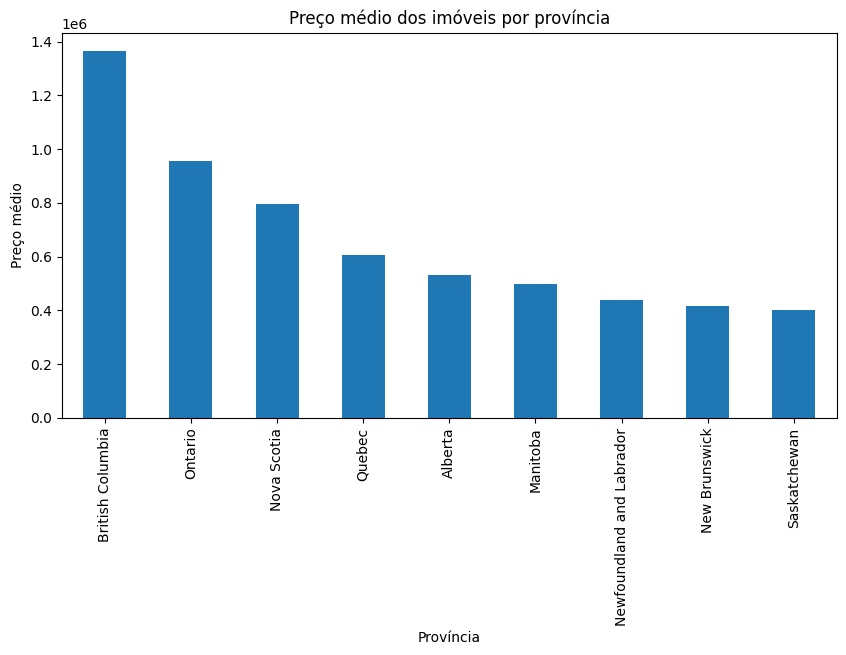

In [151]:
preco_medio_provincia = df.groupby("Province")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
preco_medio_provincia.plot(kind="bar")
plt.title("Preço médio dos imóveis por província")
plt.xlabel("Província")
plt.ylabel("Preço médio")
plt.show()

A análise dos preços médios por província evidencia diferenças relevantes entre as regiões do Canadá. Observa-se que províncias como British Columbia e Ontario apresentam os maiores valores médios, enquanto outras, como Saskatchewan e New Brunswick, apresentam preços significativamente menores.

Esse resultado reforça a influência da localização na formação dos preços dos imóveis, agora sob uma perspectiva regional mais ampla. A consistência entre os resultados por cidade e por província sugere que a valorização imobiliária não ocorre de forma isolada, mas sim como um padrão associado a determinadas regiões.

Além disso, a diferença observada entre as províncias indica que fatores regionais, como características econômicas e urbanas, podem estar relacionados ao comportamento dos preços no mercado imobiliário canadense.

Assim como na análise por cidade, é importante considerar que os valores médios podem ser influenciados por imóveis com preços muito elevados, o que reforça a importância da análise conjunta com a identificação de outliers.

## 21. Relação entre preço e número de quartos

Nesta etapa, busca-se verificar se imóveis com maior número de quartos tendem a apresentar preços mais elevados, conforme uma das hipóteses do projeto.

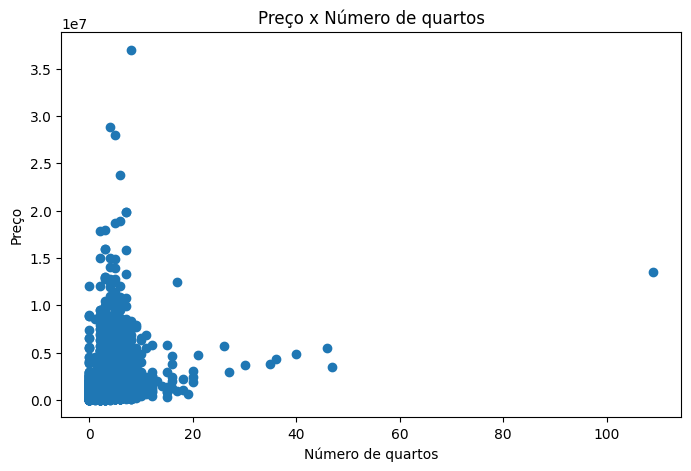

In [152]:
plt.figure(figsize=(8,5))
plt.scatter(df["Number_Beds"], df["Price"])
plt.title("Preço x Número de quartos")
plt.xlabel("Número de quartos")
plt.ylabel("Preço")
plt.show()

O gráfico de dispersão entre preço e número de quartos não evidencia uma relação linear clara entre as variáveis. Embora seja possível observar uma leve tendência de aumento de preço em imóveis com maior número de quartos, a dispersão dos pontos é bastante elevada.

A maior parte dos imóveis está concentrada em até 10 quartos, com ampla variação de preços dentro desse intervalo, o que indica que o número de quartos, isoladamente, não é suficiente para explicar o valor dos imóveis.

Além disso, observa-se a presença de valores extremos, tanto em relação ao número de quartos quanto aos preços, o que contribui para a dispersão dos dados e dificulta a identificação de padrões mais definidos.

Esse resultado sugere que outros fatores, como localização e características específicas dos imóveis, desempenham um papel relevante na formação dos preços, sendo necessário considerar múltiplas variáveis para uma análise mais completa.

Como a base apresenta valores extremos no número de quartos, foi realizado um recorte adicional considerando apenas imóveis com até 10 quartos, com o objetivo de visualizar melhor o comportamento predominante dos dados.

## 22. Relação entre preço e número de banheiros

A quantidade de banheiros também pode estar associada ao padrão do imóvel. O gráfico abaixo permite avaliar visualmente essa relação.

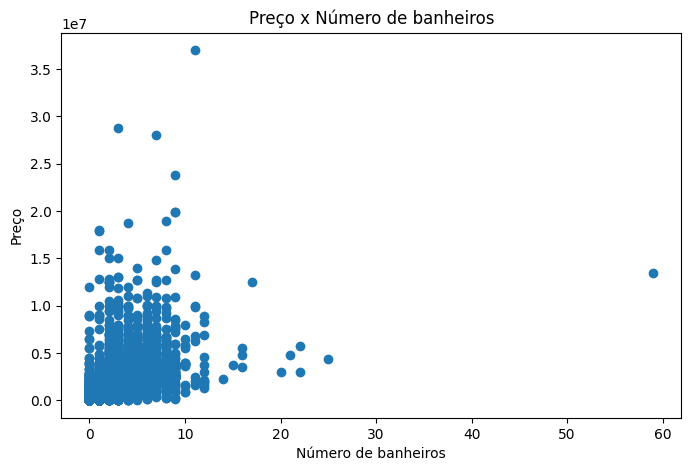

In [153]:
plt.figure(figsize=(8,5))
plt.scatter(df["Number_Baths"], df["Price"])
plt.title("Preço x Número de banheiros")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço")
plt.show()

O gráfico de dispersão entre preço e número de banheiros apresenta comportamento semelhante ao observado na relação com o número de quartos. Embora exista uma leve tendência de aumento de preço em imóveis com maior quantidade de banheiros, a dispersão dos dados é elevada, não evidenciando uma relação linear clara entre as variáveis.

A maior parte dos imóveis está concentrada entre 1 e 5 banheiros, com ampla variação de preços dentro desse intervalo, o que indica que o número de banheiros, isoladamente, não é suficiente para explicar o valor dos imóveis.

Além disso, a presença de valores extremos, tanto em termos de número de banheiros quanto de preços, contribui para a dispersão dos dados e dificulta a identificação de padrões mais definidos.

Esse resultado, em conjunto com a análise anterior, reforça que a formação dos preços no mercado imobiliário depende de múltiplos fatores, sendo necessário considerar variáveis adicionais, como localização e características específicas dos imóveis, para uma compreensão mais completa.

## 23. Correlação entre variáveis numéricas

A matriz de correlação ajuda a identificar relações lineares entre as variáveis numéricas da base, permitindo observar quais atributos estão mais associados ao preço dos imóveis.

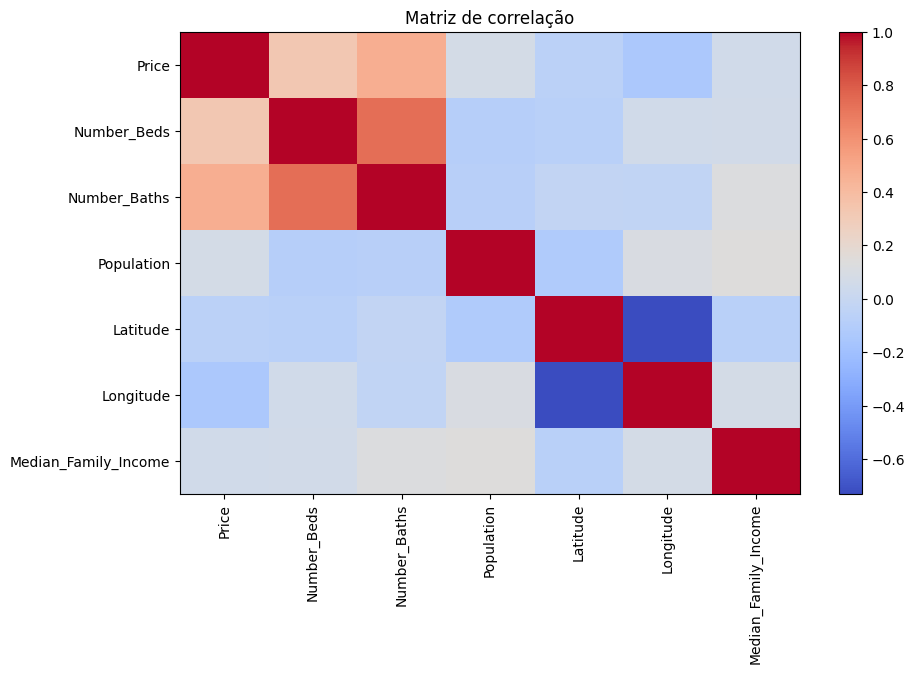

In [154]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlação")
plt.show()

A matriz de correlação evidencia que nenhuma das variáveis analisadas apresenta uma relação linear forte com o preço dos imóveis.

Observa-se que as variáveis relacionadas às características dos imóveis, como número de quartos e número de banheiros, possuem correlação positiva moderada com o preço, indicando que imóveis maiores tendem a apresentar valores mais elevados. No entanto, essas variáveis, isoladamente, não explicam de forma significativa a variação dos preços.

As variáveis relacionadas à localização, como latitude e longitude, apresentam correlação fraca ou negativa com o preço, sugerindo que essas medidas não capturam de forma adequada as diferenças regionais observadas anteriormente na análise por cidade e província.

Além disso, variáveis como população e renda familiar mediana também apresentam baixa correlação com o preço, indicando que outros fatores podem estar envolvidos na formação dos valores dos imóveis.

De forma geral, os resultados reforçam que o preço dos imóveis é influenciado por múltiplas variáveis e que análises mais completas devem considerar a combinação de diferentes fatores, e não apenas relações isoladas.

# Pré-Processamento de Dados

## 24. Pré-processamento dos dados

Após a análise exploratória, inicia-se a etapa de pré-processamento, com o objetivo de melhorar a qualidade da base e prepará-la para usos futuros.

In [155]:
df_tratado = df.copy()

In [156]:
df_tratado = df_tratado.drop_duplicates()
print(f"Quantidade de linhas após remoção de duplicados: {df_tratado.shape[0]}")

Quantidade de linhas após remoção de duplicados: 33252


In [157]:
df_tratado.isnull().sum().sort_values(ascending=False)

,0
City,0
Price,0
Address,0
Number_Beds,0
Number_Baths,0
Province,0
Population,0
Latitude,0
Longitude,0
Median_Family_Income,0


In [158]:
colunas_numericas = ["Price", "Number_Beds", "Number_Baths", "Population", "Latitude", "Longitude", "Median_Family_Income"]

for col in colunas_numericas:
    if df_tratado[col].isnull().sum() > 0:
        df_tratado[col] = df_tratado[col].fillna(df_tratado[col].median())

In [159]:
colunas_categoricas = ["City", "Address", "Province"]

for col in colunas_categoricas:
    if df_tratado[col].isnull().sum() > 0:
        df_tratado[col] = df_tratado[col].fillna(df_tratado[col].mode()[0])

In [160]:
df_tratado.isnull().sum().sort_values(ascending=False)

,0
City,0
Price,0
Address,0
Number_Beds,0
Number_Baths,0
Province,0
Population,0
Latitude,0
Longitude,0
Median_Family_Income,0


## 25. Tratamento de outliers da variável preço

Como bases imobiliárias costumam apresentar valores extremos, será aplicado um critério baseado no intervalo interquartil (IQR) para identificar possíveis outliers na variável preço.

In [161]:
Q1 = df_tratado["Price"].quantile(0.25)
Q3 = df_tratado["Price"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_tratado = df_tratado[(df_tratado["Price"] >= limite_inferior) & (df_tratado["Price"] <= limite_superior)]

print(f"Quantidade de linhas após tratamento de outliers: {df_tratado.shape[0]}")

Quantidade de linhas após tratamento de outliers: 30836


In [162]:
print("Base original:", df.shape)
print("Base tratada:", df_tratado.shape)

Base original: (35768, 10)
Base tratada: (30836, 10)


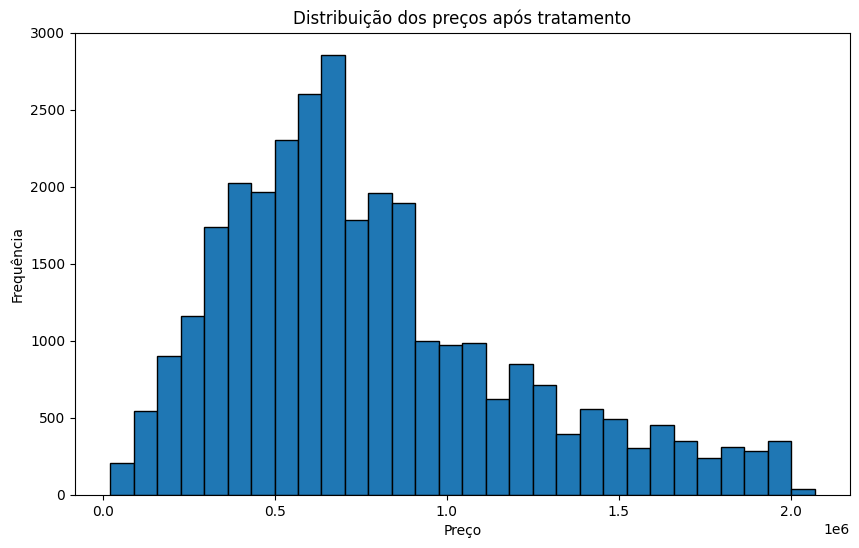

In [163]:
plt.figure(figsize=(10,6))
plt.hist(df_tratado["Price"], bins=30, edgecolor="black")
plt.title("Distribuição dos preços após tratamento")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

Após a aplicação do critério do intervalo interquartil (IQR) para a variável preço, a base passou de 35.768 para 30.836 registros, o que indica a remoção de 4.932 observações consideradas extremas.

Esse resultado mostra que a presença de outliers era significativa na base, confirmando as evidências já observadas nas estatísticas descritivas, no histograma original e no boxplot.

O histograma após o tratamento apresenta uma distribuição mais concentrada e representativa do comportamento predominante dos preços, reduzindo a influência de imóveis com valores muito elevados. Embora a distribuição ainda permaneça assimétrica à direita, a visualização se torna mais adequada para análises posteriores.

Dessa forma, o tratamento de outliers contribuiu para melhorar a qualidade analítica da base, tornando os dados mais apropriados para interpretações gerais e para possíveis etapas futuras de modelagem.

## 26. Preparação adicional dos dados para modelagem

Após as etapas de limpeza e tratamento dos dados, foram realizadas transformações adicionais com o objetivo de preparar a base para possíveis aplicações de modelagem. Essas transformações incluem padronização de variáveis numéricas, codificação de variáveis categóricas e discretização de variáveis relevantes.

In [164]:
from sklearn.preprocessing import StandardScaler

# Base tratada
df_modelo = df_tratado.copy()

# 1. Padronização de variáveis numéricas
colunas_numericas = ["Price", "Population", "Latitude", "Longitude", "Median_Family_Income"]
scaler = StandardScaler()

df_padronizado = df_modelo.copy()
df_padronizado[colunas_numericas] = scaler.fit_transform(df_padronizado[colunas_numericas])

df_padronizado.head()

,City,Price,Address,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
0,Toronto,0.012368,#318 -20 SOUTHPORT ST,3,2,Ontario,4.487559,-1.044153,0.802174,0.588665
1,Toronto,0.059723,#818 -60 SOUTHPORT ST,3,1,Ontario,4.487559,-1.044153,0.802174,0.588665
2,Toronto,0.059490,#714 -859 THE QUEENSWAY,2,2,Ontario,4.487559,-1.044153,0.802174,0.588665
3,Toronto,1.002174,275 MORTIMER AVE,4,2,Ontario,4.487559,-1.044153,0.802174,0.588665
4,Toronto,-0.249397,#420 -388 RICHMOND ST,1,1,Ontario,4.487559,-1.044153,0.802174,0.588665


A padronização foi aplicada às variáveis numéricas para colocá-las em escalas comparáveis, evitando que variáveis com valores muito altos tenham peso desproporcional em algoritmos de modelagem.

In [165]:
# 2. One-hot encoding para variáveis categóricas
df_encoded = pd.get_dummies(df_modelo, columns=["City", "Province"], drop_first=True)

df_encoded.head()

,Price,Address,Number_Beds,Number_Baths,Population,Latitude,Longitude,Median_Family_Income,City_Airdrie,City_Barrie,...,City_Windsor,City_Winnipeg,Province_British Columbia,Province_Manitoba,Province_New Brunswick,Province_Newfoundland and Labrador,Province_Nova Scotia,Province_Ontario,Province_Quebec,Province_Saskatchewan
0,779900.0,#318 -20 SOUTHPORT ST,3,2,5647656,43.7417,-79.3733,97000.0,False,False,...,False,False,False,False,False,False,False,True,False,False
1,799999.0,#818 -60 SOUTHPORT ST,3,1,5647656,43.7417,-79.3733,97000.0,False,False,...,False,False,False,False,False,False,False,True,False,False
2,799900.0,#714 -859 THE QUEENSWAY,2,2,5647656,43.7417,-79.3733,97000.0,False,False,...,False,False,False,False,False,False,False,True,False,False
3,1200000.0,275 MORTIMER AVE,4,2,5647656,43.7417,-79.3733,97000.0,False,False,...,False,False,False,False,False,False,False,True,False,False
4,668800.0,#420 -388 RICHMOND ST,1,1,5647656,43.7417,-79.3733,97000.0,False,False,...,False,False,False,False,False,False,False,True,False,False


O one-hot encoding foi utilizado para transformar variáveis categóricas, como cidade e província, em colunas numéricas, permitindo seu uso em modelos de aprendizado de máquina.

In [166]:
# 3. Discretização do preço em faixas
df_discretizado = df_modelo.copy()
df_discretizado["Faixa_Preco"] = pd.qcut(df_discretizado["Price"], q=4, labels=["Baixo", "Médio", "Alto", "Muito Alto"])

df_discretizado[["Price", "Faixa_Preco"]].head()

,Price,Faixa_Preco
0,779900.0,Alto
1,799999.0,Alto
2,799900.0,Alto
3,1200000.0,Muito Alto
4,668800.0,Médio


A discretização do preço em quartis foi realizada com o objetivo de criar faixas de valor, facilitando análises comparativas e possíveis aplicações futuras em problemas de classificação.

Essas transformações não alteram a análise exploratória realizada anteriormente, mas tornam o conjunto de dados mais adequado para algoritmos de aprendizado de máquina, que geralmente exigem variáveis numéricas em escala comparável e não lidam diretamente com variáveis categóricas.

# Respondendo nossas hipóteses

## Hipótese 1: Imóveis com mais quartos tendem a ter preços mais altos?
Os resultados indicam uma tendência positiva entre número de quartos e preço, porém com alta dispersão, o que mostra que essa variável, isoladamente, não explica completamente o valor dos imóveis.

**Evidências que sustentam essa conclusão:**
- **Tabela de estatísticas descritivas**: mostrou que a maior parte dos imóveis possui entre 2 e 4 quartos, o que ajuda a caracterizar o perfil predominante da base.
- **Gráfico de distribuição do número de quartos**: evidenciou a concentração de imóveis com 2, 3 e 4 quartos e a presença de valores extremos.
- **Gráfico de dispersão entre preço e número de quartos**: foi a principal visualização para esta hipótese, mostrando leve tendência positiva, porém com alta dispersão.
- **Matriz de correlação**: reforçou que a relação entre número de quartos e preço é apenas moderada, e não forte o suficiente para explicar sozinha a variação dos preços.

## Hipótese 2: A localização influencia o preço dos imóveis?
Sim, a análise por cidade e província mostrou diferenças significativas nos preços médios, indicando que a localização é um fator relevante na formação dos preços.

**Evidências que sustentam essa conclusão:**
- **Gráfico de preços médios por cidade**: mostrou diferenças expressivas entre os mercados imobiliários das cidades analisadas.
- **Gráfico de preços médios por província**: confirmou que essas diferenças também aparecem em nível regional.
- **Tabela de estatísticas descritivas**: mostrou variação em variáveis relacionadas ao contexto geográfico, como população e renda mediana.
- **Matriz de correlação**: indicou que latitude e longitude, isoladamente, não explicam bem o preço, sugerindo que a localização é melhor capturada pelas categorias cidade e província do que apenas pelas coordenadas geográficas.


## Hipótese 3: Variáveis como renda e população estão associadas ao preço?
As análises mostraram correlação fraca entre essas variáveis e o preço, sugerindo que seu impacto é limitado quando analisadas isoladamente.

**Evidências que sustentam essa conclusão:**
- **Tabela de estatísticas descritivas**: mostrou que população e renda familiar mediana variam entre as localidades, o que justificou investigá-las.
- **Matriz de correlação**: foi a principal evidência para esta hipótese, indicando associação fraca entre preço, população e renda familiar mediana.
- **Células descritivas da análise exploratória**: reforçaram que essas variáveis, apesar de relevantes para caracterizar o contexto dos imóveis, não apresentaram relação linear forte com o preço.

# 27. Conclusão

A análise exploratória permitiu compreender de forma mais detalhada a estrutura da base de imóveis em cidades canadenses e identificar padrões relevantes relacionados ao preço dos imóveis.

Os resultados mostraram que a base possui boa completude, sem valores ausentes, mas com presença de registros duplicados, o que exigiu tratamento na etapa de pré-processamento. Também foi identificada uma quantidade significativa de outliers, especialmente na variável preço, além de valores extremos nas variáveis número de quartos e número de banheiros.

Em relação ao comportamento dos dados, observou-se que a distribuição dos preços é fortemente assimétrica à direita, com concentração de imóveis em faixas de valor mais baixas e presença de poucos imóveis com preços muito elevados. As análises também indicaram que a maior parte dos imóveis da base possui entre 2 e 4 quartos e entre 2 e 3 banheiros, caracterizando um perfil predominante de imóveis de porte médio.

A análise por localização evidenciou diferenças importantes entre cidades e províncias, reforçando que o mercado imobiliário não se comporta de forma homogênea no Canadá. Além disso, as relações entre preço, número de quartos e número de banheiros mostraram tendência positiva, porém com alta dispersão, indicando que essas variáveis, isoladamente, não explicam de forma suficiente a variação dos preços.

A matriz de correlação confirmou que nenhuma variável individual apresenta associação linear forte com o preço, sugerindo que a formação do valor dos imóveis depende da combinação de múltiplos fatores.

Por fim, o pré-processamento contribuiu para melhorar a qualidade analítica da base, com remoção de duplicados e tratamento de outliers na variável preço, tornando o conjunto de dados mais adequado para análises futuras e possíveis aplicações de modelagem preditiva.